<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W04_Part_1_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-4 Assignment: clustering_with_ground_truth.csv
___
Name: Arief Purnama Muharram<br>
Student number: 23521013

In [ ]:
# Install the requirement modules.

!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install yellowbrick
!pip install kneed

In [ ]:
# Connect Google Drive.

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Pre-processing
___

In [ ]:
# Import the data.
# data: clustering_with_ground_truth.csv

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/clustering_with_ground_truth.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   species  85 non-null     object 
 1   weight   85 non-null     float64
 2   length1  85 non-null     float64
 3   length2  85 non-null     float64
 4   length3  85 non-null     float64
 5   height   85 non-null     float64
 6   width    85 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.8+ KB


In [ ]:
# Check if there is null data.

df.isnull().any().any()

False

In [ ]:
# Reduce data dimensionality.
# Take the length mean instead of length1, length2, and length3.

df['length_mean'] = round((df['length1'] + df['length2'] + df['length3']) / 3, 2)

df.drop(['length1', 'length2', 'length3'], axis=1, inplace=True)

df = df.reindex(columns=['species', 'weight', 'length_mean', 'height', 'width'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   species      85 non-null     object 
 1   weight       85 non-null     float64
 2   length_mean  85 non-null     float64
 3   height       85 non-null     float64
 4   width        85 non-null     float64
dtypes: float64(4), object(1)
memory usage: 3.4+ KB


In [ ]:
# Print the top-5 of the data.

df.head(5)

,species,weight,length_mean,height,width
0,Bream,242.0,26.20,38.4,13.4
1,Bream,290.0,27.17,40.0,13.8
2,Bream,340.0,27.17,39.8,15.1
3,Bream,363.0,29.60,38.0,13.3
4,Bream,430.0,29.83,36.6,15.1


In [ ]:
# Print species size of the data.

df.groupby(by=['species']).size()

species
Bream    34
Pike     17
Roach    20
Smelt    14
dtype: int64

In [ ]:
# Data description.

df.describe()

,weight,length_mean,height,width
count,85.000000,85.000000,85.000000,85.000000
mean,431.758824,30.006118,28.076471,12.865882
std,380.933962,12.206111,10.351543,2.117476
min,0.000000,9.970000,14.500000,8.700000
25%,120.000000,21.370000,16.900000,11.000000
50%,390.000000,31.800000,27.100000,13.700000
75%,650.000000,36.730000,39.200000,14.700000
max,1650.000000,63.470000,44.500000,16.100000


In [ ]:
# Drop extreme value.
# I find the zero value at weight attribute, which seems impossible or due to 
# error in measurement. Therefore, it is better to remove it from the dataset.

df.drop(df[df.weight == 0].index, inplace=True)

In [ ]:
# Rule out the ground truth attribute (species).

from sklearn.preprocessing import normalize

X = df.drop(['species'], axis=1, inplace=False)

X_scaled = normalize(X)

y = df['species']

## Partitioning Methods (K-Means)
____
References:<br>
<ul>
<li>Scikit-learn: Machine Learning in Python, <i>Pedregosa et al.</i>, JMLR 12, pp. 2825-2830, 2011.</li>
<li>K-means for 3 variables, <i>Shravan</i>, Medium, Available from: https://medium.com/@sk.shravan00/k-means-for-3-variables-260d20849730</li>
<li>Hands-on K-Means clustering, <i>Pramoditha R</i>, Medium, available from: https://medium.com/mlearning-ai/k-means-clustering-with-scikit-learn-e2af706450e4</li>
</ul>

Silhouette score for k =  2 is  0.5786251730078147
Silhouette score for k =  3 is  0.6102042680273394
Silhouette score for k =  4 is  0.6063153027763566
Silhouette score for k =  5 is  0.6246714440458256
Silhouette score for k =  6 is  0.6055382661660782
Silhouette score for k =  7 is  0.6461645052590247
Silhouette score for k =  8 is  0.6514636952748619
Silhouette score for k =  9 is  0.6503813712866026
Silhouette score for k =  10 is  0.6415023481214513


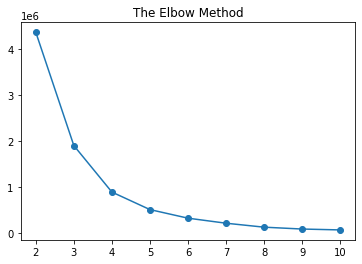

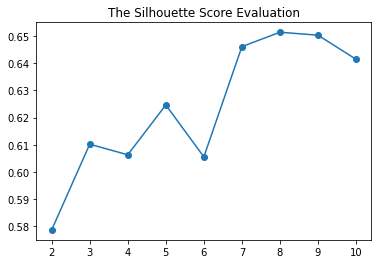

In [ ]:
# K-Means clustering model.
# Initialize the cluster using K-Means++ algorithm.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_range = range(2, 11)

data = X

distortions = []

silhouette_scores = []

for k in cluster_range:
  model = KMeans(n_clusters=k, init='k-means++', random_state=0)
  model.fit(data)

  # Append the model inertia.
  distortions.append(model.inertia_)

  # Append the silhouette score.
  score = silhouette_score(data, model.labels_)
  silhouette_scores.append(score)
  print("Silhouette score for k = ", k, "is ", score)

plt.figure(1)
plt.title("The Elbow Method")
plt.plot(cluster_range, distortions, marker='o')

plt.figure(2)
plt.title("The Silhouette Score Evaluation")
plt.plot(cluster_range, silhouette_scores, marker='o')

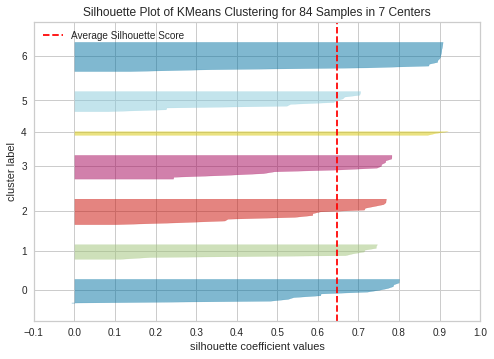

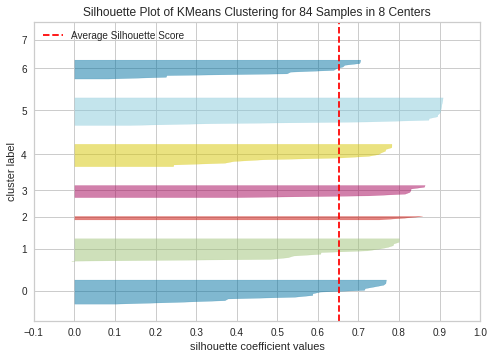

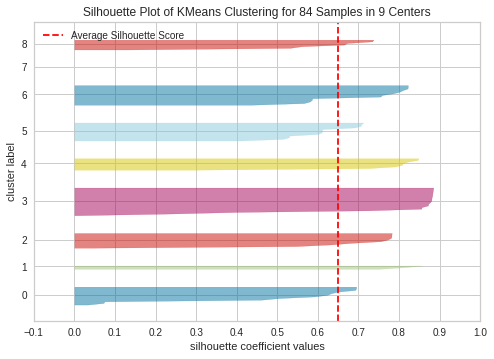

In [ ]:
# Which one is the best?
# From the Silhouette Score visualization we obtained the best score on
# arround 'k' of 7, 8, and 9. So, we use Silhouette Diagram Visualization
# in order to determine which one is the best.

from yellowbrick.cluster import SilhouetteVisualizer

clusters = [7,8,9]

for k in clusters:
  model = KMeans(n_clusters=k, random_state=0)
  viz = SilhouetteVisualizer(model, init='k-means++', colors='yellowbrick')
  viz.fit(data)
  viz.show()

In [ ]:
# The Silhouette Diagram Visualization show kind the same distribution
# for each clusters. Therefore, based on the Silhouette Score, I choose
# 'k' equal to 8 as the optimum 'k' value.

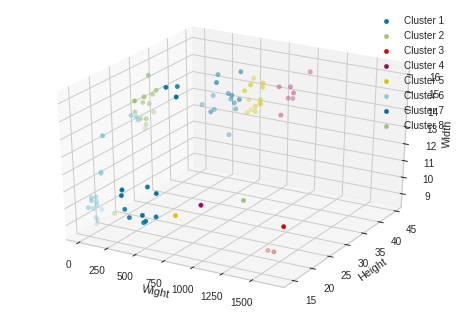

In [ ]:
# 3D-visualization of the clusters.
# Maximum dimension is 3, so I choose to visualize it based on their
# weight, height, and width.

model = KMeans(n_clusters=8, init='k-means++', random_state=0)

_y = model.fit_predict(data)

X['cluster'] = _y
cluster_1 = X[X.cluster==0]
cluster_2 = X[X.cluster==1]
cluster_3 = X[X.cluster==2]
cluster_4 = X[X.cluster==3]
cluster_5 = X[X.cluster==4]
cluster_6 = X[X.cluster==5]
cluster_7 = X[X.cluster==6]
cluster_8 = X[X.cluster==7]

kplot = plt.axes(projection='3d')
kplot.set_xlabel("Wight")
kplot.set_ylabel("Height")
kplot.set_zlabel("Width")
kplot.scatter3D(cluster_1.weight, cluster_1.height, cluster_1.width, cmap='rainbow', label='Cluster 1')
kplot.scatter3D(cluster_2.weight, cluster_2.height, cluster_2.width, cmap='rainbow', label='Cluster 2')
kplot.scatter3D(cluster_3.weight, cluster_3.height, cluster_3.width, cmap='rainbow', label='Cluster 3')
kplot.scatter3D(cluster_4.weight, cluster_4.height, cluster_4.width, cmap='rainbow', label='Cluster 4')
kplot.scatter3D(cluster_5.weight, cluster_5.height, cluster_5.width, cmap='rainbow', label='Cluster 5')
kplot.scatter3D(cluster_6.weight, cluster_6.height, cluster_6.width, cmap='rainbow', label='Cluster 6')
kplot.scatter3D(cluster_7.weight, cluster_7.height, cluster_7.width, cmap='rainbow', label='Cluster 7')
kplot.scatter3D(cluster_8.weight, cluster_8.height, cluster_8.width, cmap='rainbow', label='Cluster 8')
plt.legend()

## Hierarchial Methods
___
References:<br>
<ul>
<li>Implementing agglomerative clustering using SKlearn, available from: https://www.geeksforgeeks.org/implementing-agglomerative-clustering-using-sklearn/</li>
</ul>

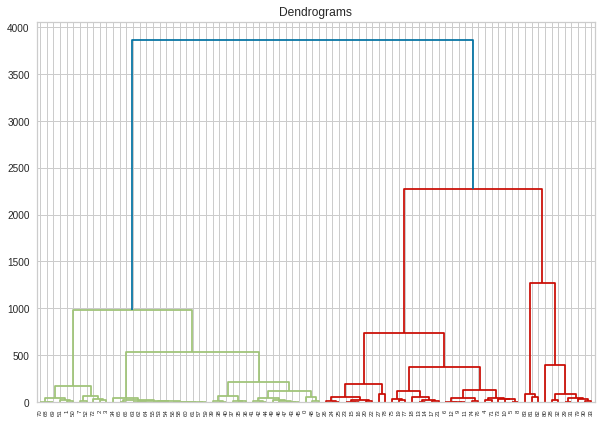

In [ ]:
# Visualize the dendrogram.

import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X, method='ward'))

Silhouette score for k =  2 is  0.5783573565884603
Silhouette score for k =  3 is  0.5946155114946867
Silhouette score for k =  4 is  0.6116810509001495
Silhouette score for k =  5 is  0.5329702651603465
Silhouette score for k =  6 is  0.5711327414763696
Silhouette score for k =  7 is  0.6035806132543623
Silhouette score for k =  8 is  0.6084549984447895


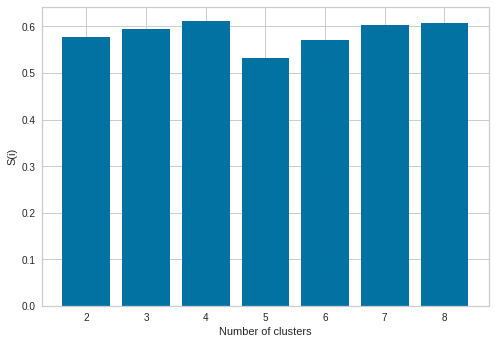

In [ ]:
# Agglomerative clustering.
# Determine the best n clusters using Silhouette Score method.

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

cluster_range = range(2,9)

silhouette_scores = []

for k in cluster_range:
  model = AgglomerativeClustering(n_clusters=k, affinity='euclidean', linkage='ward')
  score = silhouette_score(X, model.fit_predict(X))
  silhouette_scores.append(score)
  print("Silhouette score for k = ", k, "is ", score)

# Plotting a bar graph to compare the result.
plt.bar(cluster_range, silhouette_scores)
plt.xlabel('Number of clusters')
plt.ylabel('S(i)')
plt.show()


In [ ]:
# Based on the Silhouette Score, we choose k=4 as the best
# number of clusters.

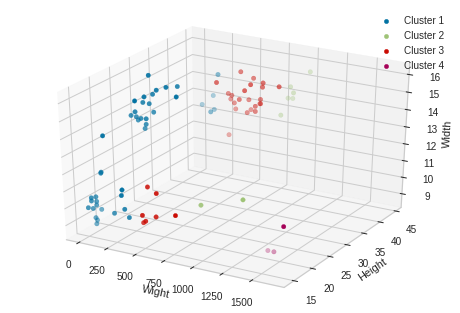

In [ ]:
# 3D-visualization of the clusters.
# Maximum dimension is 3, so I choose to visualize it based on their
# weight, height, and width.

model = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
_y = model.fit_predict(data)

X['cluster'] = _y
cluster_1 = X[X.cluster==0]
cluster_2 = X[X.cluster==1]
cluster_3 = X[X.cluster==2]
cluster_4 = X[X.cluster==3]

kplot = plt.axes(projection='3d')
kplot.set_xlabel("Wight")
kplot.set_ylabel("Height")
kplot.set_zlabel("Width")
kplot.scatter3D(cluster_1.weight, cluster_1.height, cluster_1.width, cmap='rainbow', label='Cluster 1')
kplot.scatter3D(cluster_2.weight, cluster_2.height, cluster_2.width, cmap='rainbow', label='Cluster 2')
kplot.scatter3D(cluster_3.weight, cluster_3.height, cluster_3.width, cmap='rainbow', label='Cluster 3')
kplot.scatter3D(cluster_4.weight, cluster_4.height, cluster_4.width, cmap='rainbow', label='Cluster 4')
plt.legend()

## Density-based Method (DBSCAN)
___
References:<br>
<ul>
<li>Tutorial for DBSCAN clustering in Python SKlearn, <i>Kumar V</i>, available from: https://machinelearningknowledge.ai/tutorial-for-dbscan-clustering-in-python-sklearn/</li>
<li>DBSCAN parameter estimation using Python, <i>Mullin T</i>, Medium, available from: https://medium.com/@tarammullin/dbscan-parameter-estimation-ff8330e3a3bd</li>
</ul>

In [ ]:
# Minimum samples ("MinPts")
# There is no automatic way to determine the MinPts value for DBSCAN.
# If the data has more than 2 dimensions, choose MinPts = 2 * dim,
# where dim = the dimension of the dataset (Sander et al., 1998).
#
# Therefore, the MinPts of this dataset is 8 (2*4).

min_pts = 8

Epsilon value: 0.04455402298421274


<Figure size 360x360 with 0 Axes>

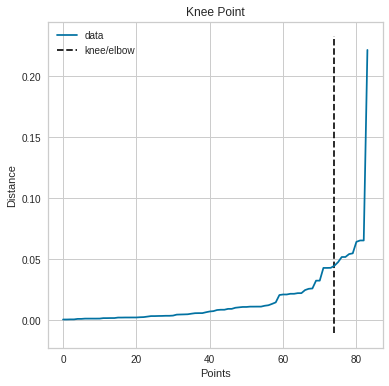

In [ ]:
# Determine the Epsilon value.

import numpy as np
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

nearest_neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors = nearest_neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,1]

i = np.arange(len(distances))
knee = KneeLocator(i, distances, S=1, curve='convex', direction='increasing', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")

epsilon = distances[knee.knee]
print('Epsilon value:', epsilon)

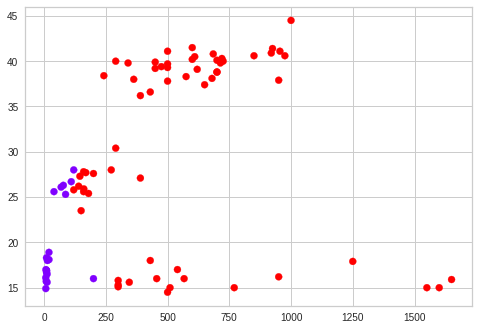

In [ ]:
# DBSCAN model.

from sklearn.cluster import DBSCAN

model = DBSCAN(eps=epsilon, min_samples=min_pts)
model.fit_predict(X_scaled)

plt.scatter(X['weight'], X['height'], c=model.labels_, cmap='rainbow')

In [ ]:
# Silhouette score evaluation.

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, model.fit_predict(X_scaled))
print("The Silhouette score is", score)

The Silhouette score is 0.7413255863822167
